# 模型式强化学习 — Dyna-Q 的边界实验

本实验不把规划计算冒充环境样本。中心问题：在固定真实交互预算下，模型质量与规划分配如何共同决定收益？验证 `model-based-rl.tex` 中的核心结论：

1. **样本效率**：固定真实步数下，不同规划预算 $n$ 的贪心评估回报（CliffWalking，确定性转移）；
2. **数据 vs 计算**：规划带来的收益与墙钟时间代价；
3. **模型偏差**：随机环境（FrozenLake）中 last-observation 模型与 empirical 计数模型的差异。

所有训练曲线按真实环境步数对齐，并在固定检查点用无探索的贪心策略评估。

输出图：
- `fig1_sample_efficiency.pdf`
- `fig2_planning_sweep.pdf`
- `fig3_model_bias.pdf`

In [ ]:
BREAKRL_CHAPTER = 'model-based-rl'

import sys

if 'google.colab' in sys.modules:
    import runpy
    import urllib.request
    from pathlib import Path

    _setup = Path('/content/_breakrl_colab_setup.py')
    _req = urllib.request.Request(
        'https://raw.githubusercontent.com/Powfu-zwx/BreakRL/main/scripts/colab_setup.py' + '?v=2',
        headers={'Cache-Control': 'no-cache'},
    )
    _setup.write_bytes(urllib.request.urlopen(_req).read())
    runpy.run_path(str(_setup))['setup'](BREAKRL_CHAPTER)


In [1]:
from pathlib import Path
import json
import tempfile
import time
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

OUTDIR = Path('.')
RAW_RESULTS = Path(tempfile.gettempdir()) / 'breakrl-model-based-rl' / 'dyna_q_raw_results.json'
SEEDS = list(range(42, 62))
PLANNING_STEPS = [0, 1, 5, 20, 50]
CHECKPOINTS = np.arange(0, 2001, 100)
GAMMA, ALPHA, EPSILON = 0.95, 0.1, 0.1
EVAL_EPISODES = 20
plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})

In [2]:
def q_update(q, s, a, r, ns, terminated):
    target = r if terminated else r + GAMMA * np.max(q[ns])
    q[s, a] += ALPHA * (target - q[s, a])


def evaluate(env, q, seed, episodes=EVAL_EPISODES):
    values, lengths = [], []
    for i in range(episodes):
        state, _ = env.reset(seed=seed * 1000 + i)
        total = 0.0
        for length in range(1, 201):
            state, reward, terminated, truncated, _ = env.step(int(np.argmax(q[state])))
            total += reward
            if terminated or truncated:
                break
        values.append(total); lengths.append(length)
    return float(np.mean(values)), float(np.mean(lengths)), float(np.mean(np.asarray(values) > 0))


def train_dyna(env_name, planning_steps, seed, model_kind='empirical', total_steps=2000):
    train_env = gym.make(env_name, is_slippery=(env_name == 'FrozenLake-v1'))
    eval_env = gym.make(env_name, is_slippery=(env_name == 'FrozenLake-v1'))
    if hasattr(train_env.action_space, 'seed'):
        train_env.action_space.seed(seed)
    if hasattr(eval_env.action_space, 'seed'):
        eval_env.action_space.seed(seed + 100000)
    rng = np.random.default_rng(seed)
    q = np.zeros((train_env.observation_space.n, train_env.action_space.n))
    model, seen = {}, []
    records = []
    state, _ = train_env.reset(seed=seed)
    started = time.perf_counter()
    for step in range(total_steps + 1):
        if step in CHECKPOINTS:
            score, length, success = evaluate(eval_env, q, seed, episodes=EVAL_EPISODES)
            records.append({'step': step, 'eval_return': score, 'eval_length': length, 'success': success,
                            'planning_updates': step * planning_steps, 'coverage': len(seen),
                            'wall_seconds': time.perf_counter() - started})
        if step == total_steps:
            break
        action = int(rng.integers(train_env.action_space.n)) if rng.random() < EPSILON else int(np.argmax(q[state]))
        ns, reward, terminated, truncated, _ = train_env.step(action)
        episode_done = terminated or truncated
        q_update(q, state, action, reward, ns, terminated)
        key = (int(state), action)
        if key not in model:
            seen.append(key)
            model[key] = []
        model[key].append((int(ns), float(reward), bool(terminated)))
        for _ in range(planning_steps):
            ps, pa = seen[rng.integers(len(seen))]
            outcomes = model[(ps, pa)]
            if model_kind == 'last_observation':
                pns, pr, p_terminated = outcomes[-1]
            else:
                pns, pr, p_terminated = outcomes[rng.integers(len(outcomes))]
            q_update(q, ps, pa, pr, pns, p_terminated)
        state, _ = train_env.reset(seed=seed + step + 1) if episode_done else (ns, {})
    train_env.close()
    eval_env.close()
    return records, q, model


def run_condition(env_name, n, model_kind='empirical'):
    rows = []
    for seed in SEEDS:
        records, _, model = train_dyna(env_name, n, seed, model_kind=model_kind)
        for row in records:
            rows.append({'seed': seed, 'n': n, 'model': model_kind, **row})
    return rows

---
## Figure 1 — 样本效率：固定真实步数下的规划收益

CliffWalking-v0 上不同规划预算 $n$ 的评估曲线（20 个 seeds 的贪心评估，横轴为真实环境步数而非 episode 编号）：确定性环境里模型完全正确，规划步数越多，同样的真实数据被传播得越远，收敛越快。

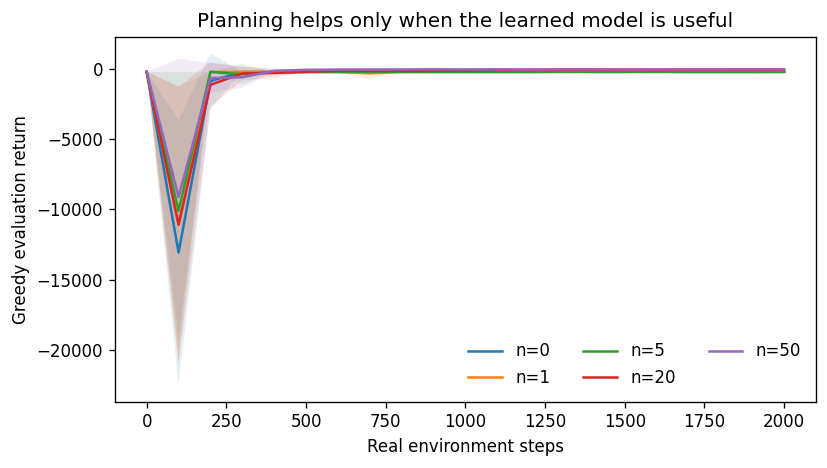

In [3]:
# Experiment 1: fixed real-step evaluation on deterministic CliffWalking.
rows = [row for n in PLANNING_STEPS for row in run_condition('CliffWalking-v0', n)]
means = {}
for n in PLANNING_STEPS:
    subset = [r for r in rows if r['n'] == n]
    means[n] = (np.array([r['eval_return'] for r in subset]).reshape(len(SEEDS), -1).mean(axis=0),
                np.array([r['eval_return'] for r in subset]).reshape(len(SEEDS), -1).std(axis=0))
fig, ax = plt.subplots(figsize=(7, 4))
for n, (mean, std) in means.items():
    ax.plot(CHECKPOINTS, mean, label=f'n={n}')
    ax.fill_between(CHECKPOINTS, mean - std, mean + std, alpha=.12)
ax.set(xlabel='Real environment steps', ylabel='Greedy evaluation return', title='Planning helps only when the learned model is useful')
ax.legend(ncol=3, frameon=False)
fig.tight_layout(); fig.savefig(OUTDIR / 'fig1_sample_efficiency.pdf', bbox_inches='tight'); plt.show()

---
## Figure 2 — 数据与计算：规划步数的收益与代价

相同 2000 个真实环境步数后的最终贪心回报（左）与墙钟时间（右，每个 $n$ 用 20 个 seeds）：规划收益随 $n$ 递增但边际递减，计算成本近似线性增长——模拟更新不计作新样本，收益的本质是「榨干已有数据」。

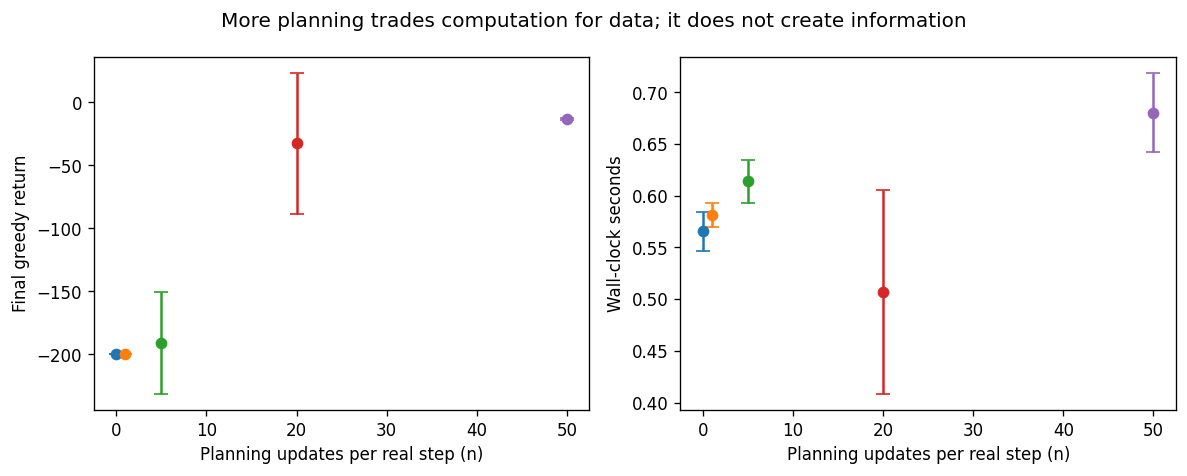

In [4]:
# Experiment 2: data versus computation. Report both real steps and planning updates.
final_rows = [r for r in rows if r['step'] == CHECKPOINTS[-1]]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for n in PLANNING_STEPS:
    subset = [r for r in final_rows if r['n'] == n]
    scores = np.array([r['eval_return'] for r in subset])
    axes[0].errorbar(n, scores.mean(), yerr=scores.std(), fmt='o', capsize=4)
    axes[1].errorbar(n, np.mean([r['wall_seconds'] for r in subset]), yerr=np.std([r['wall_seconds'] for r in subset]), fmt='o', capsize=4)
axes[0].set(xlabel='Planning updates per real step (n)', ylabel='Final greedy return')
axes[1].set(xlabel='Planning updates per real step (n)', ylabel='Wall-clock seconds')
fig.suptitle('More planning trades computation for data; it does not create information')
fig.tight_layout(); fig.savefig(OUTDIR / 'fig2_planning_sweep.pdf', bbox_inches='tight'); plt.show()

---
## Figure 3 — 模型偏差：最后观测模型 vs 经验计数模型

随机 FrozenLake-v1 中的覆盖—成功率诊断（每个点对应一个 seed，成功率来自固定、无探索的贪心评估）：last-observation 模型把随机转移记成最后一次观测，规划以偏概全；empirical 计数模型保留转移的不确定性、不再把偶然当必然。注意本实验的 (s,a) 覆盖很低，两种模型的成功率都接近 0——结论要看散点形态（模型偏差如何压制成功率），而不是绝对值。

last_observation {'success_mean': 0.0, 'coverage_mean': 19.45}
empirical {'success_mean': 0.02, 'coverage_mean': 19.05}


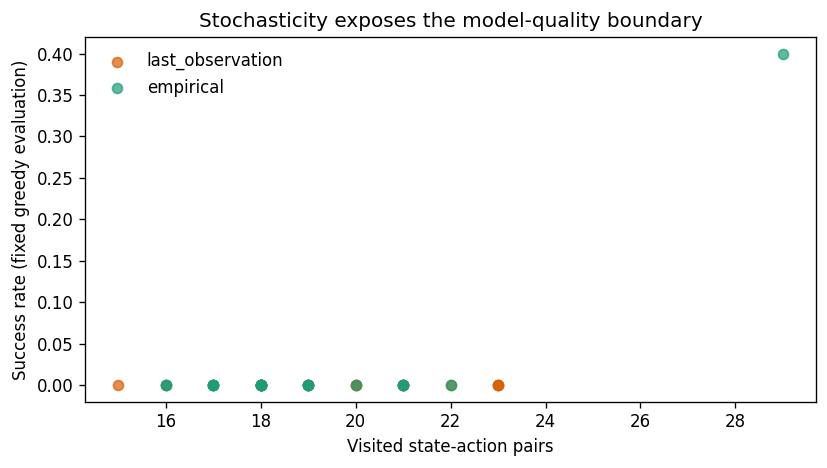

In [5]:
# Experiment 3: last observation versus empirical model on stochastic FrozenLake.
model_rows = []
for kind in ['last_observation', 'empirical']:
    model_rows.extend(run_condition('FrozenLake-v1', 20, model_kind=kind))
final = [r for r in model_rows if r['step'] == CHECKPOINTS[-1]]
fig, ax = plt.subplots(figsize=(7, 4))
for kind, color in [('last_observation', '#d95f02'), ('empirical', '#1b9e77')]:
    subset = [r for r in final if r['model'] == kind]
    x = np.array([r['coverage'] for r in subset]); y = np.array([r['success'] for r in subset])
    ax.scatter(x, y, alpha=.7, label=kind, color=color)
    print(kind, {'success_mean': float(y.mean()), 'coverage_mean': float(x.mean())})
ax.set(xlabel='Visited state-action pairs', ylabel='Success rate (fixed greedy evaluation)', title='Stochasticity exposes the model-quality boundary')
ax.legend(frameon=False); fig.tight_layout(); fig.savefig(OUTDIR / 'fig3_model_bias.pdf', bbox_inches='tight'); plt.show()
RAW_RESULTS.parent.mkdir(parents=True, exist_ok=True)
with RAW_RESULTS.open('w', encoding='utf-8') as handle:
    json.dump(rows + model_rows, handle, ensure_ascii=False, indent=2)

## 小结

- **规划的收益**来自用模型反复传播已有经验，在确定性环境中几乎免费；
- **代价**是计算：规划步数带来近似线性的墙钟成本，且收益边际递减；
- **前提**是模型质量：随机环境里，错误的模型表示（last-observation）会让规划放大偏差——模型式方法的边界由「模型有多准」决定。